# Portfolio Optimization Using Python

Many indviduals use 401Ks and different retirement tools to help prepare for life after work. Many of these tools depend on managing risk appropiately as to not incure large losses while still taking necessary risk to grow the initial capital. In this series, we will cover the topic of portfolio optimization, a popular technique that financial and investment advisors use to help ensure that their clients are taking appropriate risk to meet their financial objectives.

This tutorial will be broken into a few different sections with each section buildin on top of each other. The first section we will focus on collecting the data necessary for analysis. The data will be pretty simple, just closing price data for a small portfolio of stocks. While in this tutorial, I will focus on using the NASDAQ as my source of data I will be providing different ways on how to get this data in some supplementary code.

After we cover collecting the data, we will then move through the process of preparing the data to calculate a few different metrics that will be crucial for optaining optimial results in our portfolio. A few metrics we will calculate are expected returns, expected volatility, and the Sharpe Ratio. Once we have these metrics defined, we will then move into the process of building a simulation that will randomly generate results that we can use to help determine the optimial results for a wide range of portfolios.

We will take the results of this simulation, plot them using `matplotlib`, and then explore how we can use the `scipy` library to run an optimization algorthim that will return the best weights for our simulation.

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as sci_opt

from fake_useragent import UserAgent
from pprint import pprint
from sklearn.preprocessing import StandardScaler
import yfinance as yf

# Set some display options for Pandas.
pd.set_option('display.max_colwidth', None)
pd.set_option('expand_frame_repr', False)

In [2]:
# import pathlib
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import scipy.optimize as sci_opt
# from collections import deque
# import random
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, LSTM
# from tensorflow.keras.optimizers import Adam
# from sklearn.preprocessing import StandardScaler
# import yfinance as yf
# from fake_useragent import UserAgent
# from pprint import pprint
# import warnings
# warnings.filterwarnings('ignore')

# # Set some display options for Pandas.
# pd.set_option('display.max_colwidth', None)
# pd.set_option('expand_frame_repr', False)

# # Define the symbols
# symbols = ['AAPL', 'TSLA', 'NVDA']
# number_of_symbols = len(symbols)

# # Data loading code (same as yours)
# if not pathlib.Path('data/stock_data.csv').exists():
    
#     # Create data directory if it doesn't exist
#     pathlib.Path('data').mkdir(exist_ok=True)
    
#     # Download data for all symbols
#     stock_data = yf.download(symbols, period="3y", group_by='ticker')
    
#     # Reshape the data to have a more usable format
#     price_data_frames = []
    
#     for symbol in symbols:
#         # Get data for this symbol
#         symbol_data = stock_data[symbol].copy()
#         symbol_data.reset_index(inplace=True)
#         symbol_data['Symbol'] = symbol
        
#         # Reorder columns to put Symbol first
#         cols = ['Symbol', 'Date'] + [col for col in symbol_data.columns if col not in ['Symbol', 'Date']]
#         symbol_data = symbol_data[cols]
        
#         price_data_frames.append(symbol_data)
    
#     # Combine all dataframes
#     price_data_frame = pd.concat(price_data_frames, ignore_index=True)
    
#     # Save to CSV
#     price_data_frame.to_csv('data/stock_data.csv', index=False)

# else:
#     # Load the data.
#     price_data_frame: pd.DataFrame = pd.read_csv('data/stock_data.csv')

# # Process the data
# price_data_frame = price_data_frame[['Date', 'Symbol', 'Close']]
# price_data_frame['Date'] = pd.to_datetime(price_data_frame['Date'])
# price_data_frame = price_data_frame.pivot(
#     index='Date',
#     columns='Symbol',
#     values='Close'
# ).dropna()

# print("Stock Price Data:")
# print("="*50)
# print(price_data_frame.head())
# print(f"Data shape: {price_data_frame.shape}")
# print(f"Date range: {price_data_frame.index[0]} to {price_data_frame.index[-1]}")

# class StockPortfolioEnvironment:
#     """
#     Environment untuk portfolio optimization dengan real stock data
#     """
    
#     def __init__(self, price_data, lookback_window=20, transaction_cost=0.001, initial_balance=10000):
#         self.price_data = price_data.copy()
#         self.returns = np.log(price_data / price_data.shift(1)).dropna()
#         self.lookback_window = lookback_window
#         self.transaction_cost = transaction_cost
#         self.initial_balance = initial_balance
#         self.n_assets = len(price_data.columns)
        
#         # Technical indicators
#         self._calculate_technical_indicators()
        
#         # Normalize features
#         self.scaler = StandardScaler()
#         self._prepare_features()
        
#         # State variables
#         self.reset()
    
#     def _calculate_technical_indicators(self):
#         """Calculate technical indicators untuk enhanced state representation"""
#         self.technical_features = pd.DataFrame(index=self.price_data.index)
        
#         for col in self.price_data.columns:
#             prices = self.price_data[col]
            
#             # Moving averages
#             self.technical_features[f'{col}_MA5'] = prices.rolling(5).mean()
#             self.technical_features[f'{col}_MA20'] = prices.rolling(20).mean()
            
#             # RSI
#             delta = prices.diff()
#             gain = (delta.where(delta > 0, 0)).rolling(14).mean()
#             loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
#             rs = gain / loss
#             self.technical_features[f'{col}_RSI'] = 100 - (100 / (1 + rs))
            
#             # Volatility (20-day rolling std of returns)
#             self.technical_features[f'{col}_VOL'] = self.returns[col].rolling(20).std()
        
#         self.technical_features = self.technical_features.dropna()
    
#     def _prepare_features(self):
#         """Prepare dan normalize features"""
#         # Combine returns dan technical indicators
#         self.features = pd.concat([
#             self.returns,
#             self.technical_features
#         ], axis=1).dropna()
        
#         # Normalize features
#         feature_values = self.scaler.fit_transform(self.features.values)
#         self.normalized_features = pd.DataFrame(
#             feature_values, 
#             index=self.features.index, 
#             columns=self.features.columns
#         )
    
#     def reset(self):
#         """Reset environment ke initial state"""
#         self.current_step = self.lookback_window
#         self.current_weights = np.ones(self.n_assets) / self.n_assets
#         self.portfolio_value = self.initial_balance
#         self.cash = 0  # Cash position
#         self.portfolio_history = [self.portfolio_value]
#         self.weights_history = [self.current_weights.copy()]
#         self.returns_history = []
        
#         return self._get_state()
    
#     def _get_state(self):
#         """Get current state untuk agent"""
#         if self.current_step >= len(self.normalized_features):
#             return None
        
#         # Get historical features
#         start_idx = max(0, self.current_step - self.lookback_window)
#         end_idx = self.current_step
        
#         historical_features = self.normalized_features.iloc[start_idx:end_idx].values
        
#         # Pad jika insufficient data
#         if len(historical_features) < self.lookback_window:
#             padding = np.zeros((self.lookback_window - len(historical_features), historical_features.shape[1]))
#             historical_features = np.vstack([padding, historical_features])
        
#         # Flatten historical features
#         state_features = historical_features.flatten()
        
#         # Add current portfolio weights dan portfolio performance metrics
#         portfolio_metrics = self._get_portfolio_metrics()
        
#         # Combine all state information
#         state = np.concatenate([
#             state_features,
#             self.current_weights,
#             portfolio_metrics
#         ])
        
#         return state
    
#     def _get_portfolio_metrics(self):
#         """Get current portfolio performance metrics"""
#         if len(self.portfolio_history) < 2:
#             return np.array([0, 0, 0])  # return, volatility, sharpe
        
#         # Calculate recent performance
#         recent_returns = np.array(self.returns_history[-min(20, len(self.returns_history)):])
        
#         if len(recent_returns) == 0:
#             return np.array([0, 0, 0])
        
#         portfolio_return = np.mean(recent_returns)
#         portfolio_volatility = np.std(recent_returns) if len(recent_returns) > 1 else 0
#         sharpe_ratio = portfolio_return / portfolio_volatility if portfolio_volatility > 0 else 0
        
#         return np.array([portfolio_return, portfolio_volatility, sharpe_ratio])
    
#     def step(self, action):
#         """Execute action dan return next state, reward, done"""
#         if self.current_step >= len(self.normalized_features):
#             return None, 0, True, {}
        
#         # Convert action ke portfolio weights
#         new_weights = self._action_to_weights(action)
        
#         # Calculate transaction costs
#         weight_changes = np.abs(new_weights - self.current_weights)
#         transaction_costs = np.sum(weight_changes) * self.transaction_cost * self.portfolio_value
        
#         # Get current period returns
#         current_date = self.normalized_features.index[self.current_step]
#         current_returns = self.returns.loc[current_date].values
        
#         # Calculate portfolio return
#         portfolio_return = np.dot(self.current_weights, current_returns)
        
#         # Update portfolio value
#         old_portfolio_value = self.portfolio_value
#         self.portfolio_value = self.portfolio_value * (1 + portfolio_return) - transaction_costs
        
#         # Calculate actual return
#         actual_return = (self.portfolio_value - old_portfolio_value) / old_portfolio_value
        
#         # Calculate reward
#         reward = self._calculate_reward(portfolio_return, transaction_costs, new_weights)
        
#         # Update state
#         self.current_weights = new_weights
#         self.current_step += 1
#         self.portfolio_history.append(self.portfolio_value)
#         self.weights_history.append(self.current_weights.copy())
#         self.returns_history.append(actual_return)
        
#         # Check if done
#         done = self.current_step >= len(self.normalized_features)
        
#         next_state = self._get_state()
        
#         info = {
#             'portfolio_value': self.portfolio_value,
#             'portfolio_return': portfolio_return,
#             'transaction_costs': transaction_costs,
#             'date': current_date,
#             'weights': self.current_weights.copy()
#         }
        
#         return next_state, reward, done, info
    
#     def _action_to_weights(self, action):
#         """Convert action vector ke portfolio weights"""
#         # Use softmax untuk ensure weights sum to 1
#         exp_action = np.exp(action - np.max(action))  # Stability trick
#         weights = exp_action / np.sum(exp_action)
#         return weights
    
#     def _calculate_reward(self, portfolio_return, transaction_costs, new_weights):
#         """Calculate reward berdasarkan multiple criteria"""
#         # Base reward: portfolio return
#         base_reward = portfolio_return
        
#         # Penalty untuk transaction costs
#         cost_penalty = transaction_costs / self.portfolio_value
        
#         # Penalty untuk extreme weights (encourage diversification)
#         concentration_penalty = np.sum(new_weights ** 2) * 0.1  # Herfindahl index
        
#         # Volatility penalty
#         if len(self.returns_history) > 5:
#             recent_vol = np.std(self.returns_history[-5:])
#             volatility_penalty = recent_vol * 0.5
#         else:
#             volatility_penalty = 0
        
#         # Drawdown penalty
#         if len(self.portfolio_history) > 1:
#             peak = max(self.portfolio_history)
#             current_dd = (peak - self.portfolio_value) / peak
#             drawdown_penalty = current_dd * 2
#         else:
#             drawdown_penalty = 0
        
#         # Total reward
#         reward = (base_reward 
#                  - cost_penalty 
#                  - concentration_penalty 
#                  - volatility_penalty 
#                  - drawdown_penalty)
        
#         return reward
    
#     def get_state_size(self):
#         """Get size dari state space"""
#         dummy_state = self._get_state()
#         return len(dummy_state) if dummy_state is not None else 0
    
#     def get_action_size(self):
#         """Get size dari action space"""
#         return self.n_assets

# class AdvancedDQNAgent:
#     """
#     Advanced Deep Q-Network Agent dengan LSTM untuk portfolio optimization
#     """
    
#     def __init__(self, state_size, action_size, learning_rate=0.001):
#         self.state_size = state_size
#         self.action_size = action_size
#         self.learning_rate = learning_rate
        
#         # Hyperparameters
#         self.epsilon = 1.0
#         self.epsilon_min = 0.01
#         self.epsilon_decay = 0.995
#         self.batch_size = 32
#         self.gamma = 0.95  # Discount factor
#         self.tau = 0.001   # Soft update parameter
        
#         # Experience replay
#         self.memory = deque(maxlen=10000)
        
#         # Neural networks
#         self.q_network = self._build_model()
#         self.target_network = self._build_model()
#         self.update_target_network()
        
#         # Performance tracking
#         self.losses = []
    
#     def _build_model(self):
#         """Build advanced neural network dengan batch normalization"""
#         model = Sequential([
#             Dense(256, input_dim=self.state_size, activation='relu'),
#             Dropout(0.3),
#             Dense(128, activation='relu'),
#             Dropout(0.3),
#             Dense(64, activation='relu'),
#             Dropout(0.2),
#             Dense(32, activation='relu'),
#             Dense(self.action_size, activation='linear')  # Linear output untuk Q-values
#         ])
        
#         model.compile(
#             optimizer=Adam(learning_rate=self.learning_rate),
#             loss='huber_loss'  # More robust than MSE
#         )
        
#         return model
    
#     def remember(self, state, action, reward, next_state, done):
#         """Store experience dalam replay buffer"""
#         self.memory.append((state, action, reward, next_state, done))
    
#     def act(self, state, deterministic=False):
#         """Choose action berdasarkan epsilon-greedy policy"""
#         if not deterministic and np.random.random() <= self.epsilon:
#             # Random action (exploration)
#             action = np.random.normal(0, 1, self.action_size)
#         else:
#             # Predicted action (exploitation)
#             q_values = self.q_network.predict(state.reshape(1, -1), verbose=0)
#             action = q_values[0]
        
#         return action
    
#     def replay(self):
#         """Train agent dengan experience replay"""
#         if len(self.memory) < self.batch_size:
#             return
        
#         batch = random.sample(self.memory, self.batch_size)
        
#         # Prepare batch data
#         states = np.array([e[0] for e in batch])
#         actions = np.array([e[1] for e in batch])
#         rewards = np.array([e[2] for e in batch])
#         next_states = np.array([e[3] for e in batch if e[3] is not None])
#         dones = np.array([e[4] for e in batch])
        
#         # Current Q-values
#         current_q_values = self.q_network.predict(states, verbose=0)
        
#         # Next Q-values dari target network
#         if len(next_states) > 0:
#             next_q_values = self.target_network.predict(next_states, verbose=0)
        
#         # Update Q-values
#         targets = current_q_values.copy()
        
#         for i, (state, action, reward, next_state, done) in enumerate(batch):
#             if done:
#                 target = reward
#             else:
#                 # Double DQN: use main network untuk action selection, target network untuk evaluation
#                 next_action = np.argmax(self.q_network.predict(next_state.reshape(1, -1), verbose=0)[0])
#                 target = reward + self.gamma * next_q_values[i][next_action]
            
#             # Update target untuk current action
#             targets[i] = action * target  # Simplified update for continuous actions
        
#         # Train network
#         history = self.q_network.fit(states, targets, epochs=1, verbose=0, batch_size=self.batch_size)
#         self.losses.append(history.history['loss'][0])
        
#         # Decay epsilon
#         if self.epsilon > self.epsilon_min:
#             self.epsilon *= self.epsilon_decay
    
#     def update_target_network(self):
#         """Soft update target network"""
#         # Soft update: θ_target = τ*θ_local + (1-τ)*θ_target
#         target_weights = self.target_network.get_weights()
#         local_weights = self.q_network.get_weights()
        
#         for i in range(len(target_weights)):
#             target_weights[i] = self.tau * local_weights[i] + (1 - self.tau) * target_weights[i]
        
#         self.target_network.set_weights(target_weights)

# def train_stock_rl_portfolio(price_data, episodes=200, lookback_window=20, plot_results=True):
#     """
#     Train RL agent untuk stock portfolio optimization
#     """
    
#     # Initialize environment dan agent
#     env = StockPortfolioEnvironment(price_data, lookback_window)
    
#     # Get state size after environment is initialized
#     dummy_state = env.reset()
#     state_size = len(dummy_state)
    
#     agent = AdvancedDQNAgent(state_size, env.get_action_size())
    
#     # Training metrics
#     episode_rewards = []
#     portfolio_values = []
#     sharpe_ratios = []
    
#     print("Training Advanced RL Portfolio Agent on Real Stock Data...")
#     print("="*70)
#     print(f"State size: {state_size}")
#     print(f"Action size: {env.get_action_size()}")
#     print(f"Training period: {env.normalized_features.index[0]} to {env.normalized_features.index[-1]}")
#     print("="*70)
    
#     best_sharpe = -np.inf
#     best_weights = None
    
#     for episode in range(episodes):
#         state = env.reset()
#         total_reward = 0
#         episode_info = []
        
#         while True:
#             action = agent.act(state)
#             next_state, reward, done, info = env.step(action)
            
#             if next_state is not None:
#                 agent.remember(state, action, reward, next_state, done)
#                 episode_info.append(info)
            
#             state = next_state
#             total_reward += reward
            
#             if done:
#                 break
        
#         # Train agent
#         if len(agent.memory) > agent.batch_size:
#             agent.replay()
            
#         # Soft update target network
#         agent.update_target_network()
        
#         # Calculate episode metrics
#         if len(env.returns_history) > 20:
#             episode_returns = np.array(env.returns_history)
#             episode_sharpe = np.mean(episode_returns) / np.std(episode_returns) * np.sqrt(252) if np.std(episode_returns) > 0 else 0
#         else:
#             episode_sharpe = 0
        
#         episode_rewards.append(total_reward)
#         portfolio_values.append(env.portfolio_value)
#         sharpe_ratios.append(episode_sharpe)
        
#         # Track best performance
#         if episode_sharpe > best_sharpe:
#             best_sharpe = episode_sharpe
#             best_weights = env.current_weights.copy()
        
#         # Progress report
#         if episode % 25 == 0:
#             avg_reward = np.mean(episode_rewards[-25:]) if len(episode_rewards) >= 25 else np.mean(episode_rewards)
#             avg_portfolio_value = np.mean(portfolio_values[-25:]) if len(portfolio_values) >= 25 else np.mean(portfolio_values)
            
#             print(f"Episode {episode:3d} | "
#                   f"Avg Reward: {avg_reward:8.4f} | "
#                   f"Portfolio Value: ${avg_portfolio_value:10,.2f} | "
#                   f"Sharpe: {episode_sharpe:6.3f} | "
#                   f"Epsilon: {agent.epsilon:.3f}")
    
#     # Plot training results
#     if plot_results:
#         plot_training_results(episode_rewards, portfolio_values, sharpe_ratios, agent.losses)
    
#     return agent, env, {
#         'episode_rewards': episode_rewards,
#         'portfolio_values': portfolio_values,
#         'sharpe_ratios': sharpe_ratios,
#         'best_sharpe': best_sharpe,
#         'best_weights': best_weights
#     }

# def evaluate_trained_agent(agent, price_data, lookback_window=20):
#     """
#     Evaluate trained agent performance
#     """
    
#     # Create fresh environment untuk evaluation
#     env = StockPortfolioEnvironment(price_data, lookback_window)
#     state = env.reset()
    
#     # Disable exploration
#     agent.epsilon = 0
    
#     portfolio_history = []
#     weights_history = []
#     returns_history = []
#     dates = []
    
#     print("\nEvaluating trained agent...")
    
#     while True:
#         action = agent.act(state, deterministic=True)
#         next_state, reward, done, info = env.step(action)
        
#         portfolio_history.append(info['portfolio_value'])
#         weights_history.append(info['weights'])
#         returns_history.append(info.get('portfolio_return', 0))
#         dates.append(info['date'])
        
#         if done:
#             break
        
#         state = next_state
    
#     # Create results DataFrame
#     results_df = pd.DataFrame({
#         'Date': dates,
#         'Portfolio_Value': portfolio_history,
#         'Portfolio_Return': returns_history
#     })
    
#     # Add individual stock weights
#     weights_df = pd.DataFrame(weights_history, columns=[f'{symbol}_Weight' for symbol in price_data.columns])
#     results_df = pd.concat([results_df, weights_df], axis=1)
    
#     return results_df, portfolio_history, weights_history

# def calculate_performance_metrics(portfolio_values, returns_data, risk_free_rate=0.02):
#     """
#     Calculate comprehensive performance metrics
#     """
    
#     # Portfolio returns
#     portfolio_returns = pd.Series(portfolio_values).pct_change().dropna()
    
#     # Annualized metrics
#     annual_return = portfolio_returns.mean() * 252
#     annual_volatility = portfolio_returns.std() * np.sqrt(252)
#     sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility if annual_volatility > 0 else 0
    
#     # Maximum drawdown
#     cumulative = (1 + portfolio_returns).cumprod()
#     peak = cumulative.expanding().max()
#     drawdown = (cumulative - peak) / peak
#     max_drawdown = drawdown.min()
    
#     # Additional metrics
#     win_rate = (portfolio_returns > 0).sum() / len(portfolio_returns)
    
#     # VaR (Value at Risk) at 95% confidence
#     var_95 = np.percentile(portfolio_returns, 5)
    
#     return {
#         'Annual Return': annual_return,
#         'Annual Volatility': annual_volatility,
#         'Sharpe Ratio': sharpe_ratio,
#         'Max Drawdown': max_drawdown,
#         'Win Rate': win_rate,
#         'VaR (95%)': var_95,
#         'Total Return': (portfolio_values[-1] / portfolio_values[0] - 1),
#         'Final Portfolio Value': portfolio_values[-1]
#     }

# def plot_training_results(rewards, portfolio_values, sharpe_ratios, losses):
#     """
#     Plot training results
#     """
    
#     fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
#     # Episode rewards
#     axes[0, 0].plot(rewards)
#     axes[0, 0].set_title('Episode Rewards')
#     axes[0, 0].set_xlabel('Episode')
#     axes[0, 0].set_ylabel('Total Reward')
#     axes[0, 0].grid(True)
    
#     # Portfolio values
#     axes[0, 1].plot(portfolio_values)
#     axes[0, 1].set_title('Portfolio Values')
#     axes[0, 1].set_xlabel('Episode')
#     axes[0, 1].set_ylabel('Portfolio Value ($)')
#     axes[0, 1].grid(True)
    
#     # Sharpe ratios
#     axes[1, 0].plot(sharpe_ratios)
#     axes[1, 0].set_title('Sharpe Ratios')
#     axes[1, 0].set_xlabel('Episode')
#     axes[1, 0].set_ylabel('Sharpe Ratio')
#     axes[1, 0].grid(True)
    
#     # Training losses
#     if losses:
#         axes[1, 1].plot(losses)
#         axes[1, 1].set_title('Training Losses')
#         axes[1, 1].set_xlabel('Training Step')
#         axes[1, 1].set_ylabel('Loss')
#         axes[1, 1].grid(True)
    
#     plt.tight_layout()
#     plt.show()

# def compare_with_benchmarks(results_df, price_data):
#     """
#     Compare RL portfolio dengan various benchmarks
#     """
    
#     # Equal weight benchmark
#     equal_weights = np.ones(len(price_data.columns)) / len(price_data.columns)
#     returns = price_data.pct_change().dropna()
#     equal_weight_returns = (returns * equal_weights).sum(axis=1)
#     equal_weight_portfolio = (1 + equal_weight_returns).cumprod() * results_df['Portfolio_Value'].iloc[0]
    
#     # Buy and hold individual stocks
#     individual_portfolios = {}
#     for col in price_data.columns:
#         stock_returns = price_data[col].pct_change().dropna()
#         individual_portfolios[col] = (1 + stock_returns).cumprod() * results_df['Portfolio_Value'].iloc[0]
    
#     # Create comparison DataFrame
#     comparison_data = {
#         'Date': results_df['Date'],
#         'RL_Portfolio': results_df['Portfolio_Value'],
#         'Equal_Weight': equal_weight_portfolio.values[:len(results_df)]
#     }
    
#     # Add individual stock performances
#     for symbol in price_data.columns:
#         comparison_data[f'{symbol}_BuyHold'] = individual_portfolios[symbol].values[:len(results_df)]
    
#     comparison_df = pd.DataFrame(comparison_data)
    
#     # Calculate performance metrics untuk each strategy
#     strategies = ['RL_Portfolio', 'Equal_Weight'] + [f'{symbol}_BuyHold' for symbol in price_data.columns]
#     performance_comparison = {}
    
#     for strategy in strategies:
#         portfolio_values = comparison_df[strategy].values
#         metrics = calculate_performance_metrics(portfolio_values, price_data)
#         performance_comparison[strategy] = metrics
    
#     return comparison_df, performance_comparison

# # Main execution
# if __name__ == "__main__":
#     print("\n" + "="*80)
#     print("REINFORCEMENT LEARNING PORTFOLIO OPTIMIZATION")
#     print("REAL STOCK DATA: AAPL, TSLA, NVDA")
#     print("="*80)
    
#     # Train RL agent
#     agent, env, training_results = train_stock_rl_portfolio(
#         price_data_frame, 
#         episodes=150,
#         lookback_window=20,
#         plot_results=True
#     )
    
#     print(f"\nTraining completed!")
#     print(f"Best Sharpe Ratio achieved: {training_results['best_sharpe']:.4f}")
#     print(f"Final training portfolio value: ${training_results['portfolio_values'][-1]:,.2f}")
    
#     # Evaluate trained agent
#     print("\n" + "="*80)
#     print("EVALUATING TRAINED AGENT")
#     print("="*80)
    
#     results_df, portfolio_history, weights_history = evaluate_trained_agent(
#         agent, price_data_frame, lookbook_window=20
#     )
    
#     # Calculate performance metrics
#     performance_metrics = calculate_performance_metrics(portfolio_history, price_data_frame)
    
#     print("\nRL PORTFOLIO PERFORMANCE METRICS:")
#     print("-" * 50)
#     for metric, value in performance_metrics.items():
#         if 'Rate' in metric or 'Return' in metric or 'Ratio' in metric:
#             print(f"{metric:25s}: {value:8.4f}")
#         elif 'Value' in metric:
#             print(f"{metric:25s}: ${value:12,.2f}")
#         else:
#             print(f"{metric:25s}: {value:8.4f}")
    
#     # Show final portfolio weights
#     final_weights = weights_history[-1]
#     print(f"\nFINAL OPTIMAL PORTFOLIO WEIGHTS:")
#     print("-" * 40)
#     for i, symbol in enumerate(symbols):
#         print(f"{symbol:6s}: {final_weights[i]:7.1%}")
    
#     # Compare dengan benchmarks
#     print(f"\n" + "="*80)
#     print("BENCHMARK COMPARISON")
#     print("="*80)
    
#     comparison_df, performance_comparison = compare_with_benchmarks(results_df, price_data_frame)
    
#     # Create comparison table
#     comparison_table = pd.DataFrame(performance_comparison).T
#     print(f"\nPERFORMANCE COMPARISON:")
#     print("-" * 80)
#     print(comparison_table.round(4))
    
#     # Plot portfolio evolution
#     plt.figure(figsize=(15, 8))
    
#     plt.subplot(2, 1, 1)
#     plt.plot(results_df['Date'], results_df['Portfolio_Value'], label='RL Portfolio', linewidth=2)
#     plt.plot(comparison_df['Date'], comparison_df['Equal_Weight'], label='Equal Weight', linestyle='--')
    
#     for symbol in symbols:
#         plt.plot(comparison_df['Date'], comparison_df[f'{symbol}_BuyHold'], 
#                 label=f'{symbol} Buy&Hold', alpha=0.7)
    
#     plt.title('Portfolio Performance Comparison')
#     plt.xlabel('Date')
#     plt.ylabel('Portfolio Value ($)')
#     plt.legend()
#     plt.grid(True)
    
#     # Plot weights evolution
#     plt.subplot(2, 1, 2)
#     weights_df = pd.DataFrame(weights_history, columns=symbols)
#     weights_df['Date'] = results_df['Date']
    
#     for symbol in symbols:
#         plt.plot(weights_df['Date'], weights_df[symbol], label=f'{symbol} Weight', linewidth=2)
    
#     plt.title('Portfolio Weights Evolution')
#     plt.xlabel('Date')
#     plt.ylabel('Weight')
#     plt.legend()
#     plt.grid(True)
#     plt.ylim(0, 1)
    
#     plt.tight_layout()
#     plt.show()
    
#     print(f"\n" + "="*80)
#     print("ANALYSIS COMPLETED!")
#     print("="*80)
#     print(f"✓ RL Portfolio trained on {len(price_data_frame)} days of data")
#     print(f"✓ Final Sharpe Ratio: {performance_metrics['Sharpe Ratio']:.4f}")
#     print(f"✓ Total Return: {performance_metrics['Total Return']:.2%}")
#     print(f"✓ Max Drawdown: {performance_metrics['Max Drawdown']:.2%}")
#     print(f"✓ Win Rate: {performance_metrics['Win Rate']:.1%}")
    
#     # Save results
#     results_df.to_csv('data/rl_portfolio_results.csv', index=False)
    
#     # Additional analysis: Risk-adjusted returns
#     print(f"\nRISK-ADJUSTED PERFORMANCE:")
#     print("-" * 50)
    
#     # Calculate Information Ratio vs Equal Weight
#     rl_returns = results_df['Portfolio_Return'].values[1:]
#     equal_weight_returns = comparison_df['Equal_Weight'].pct_change().dropna().values
    
#     if len(rl_returns) == len(equal_weight_returns):
#         excess_returns = rl_returns - equal_weight_returns
#         information_ratio = np.mean(excess_returns) / np.std(excess_returns) if np.std(excess_returns) > 0 else 0
#         print(f"Information Ratio vs Equal Weight: {information_ratio:.4f}")
    
#     # Calculate Sortino Ratio (downside deviation)
#     negative_returns = results_df['Portfolio_Return'].values[results_df['Portfolio_Return'].values < 0]
#     if len(negative_returns) > 0:
#         downside_deviation = np.std(negative_returns) * np.sqrt(252)
#         sortino_ratio = (performance_metrics['Annual Return'] - 0.02) / downside_deviation
#         print(f"Sortino Ratio: {sortino_ratio:.4f}")
    
#     # Calculate Calmar Ratio (return/max drawdown)
#     if performance_metrics['Max Drawdown'] < 0:
#         calmar_ratio = performance_metrics['Annual Return'] / abs(performance_metrics['Max Drawdown'])
#         print(f"Calmar Ratio: {calmar_ratio:.4f}")
    
#     print(f"\n" + "="*80)
#     print("KEY INSIGHTS:")
#     print("="*80)
    
#     # Analyze best performing periods
#     best_month_return = results_df['Portfolio_Return'].max()
#     worst_month_return = results_df['Portfolio_Return'].min()
    
#     print(f"• Best single period return: {best_month_return:.2%}")
#     print(f"• Worst single period return: {worst_month_return:.2%}")
    
#     # Analyze portfolio concentration
#     avg_concentration = np.mean([np.sum(w**2) for w in weights_history])
#     print(f"• Average portfolio concentration (HHI): {avg_concentration:.3f}")
#     print(f"  (Lower is more diversified, 0.33 = equal weight for 3 assets)")
    
#     # Compare volatility
#     rl_volatility = performance_metrics['Annual Volatility']
#     equal_weight_vol = comparison_table.loc['Equal_Weight', 'Annual Volatility']
    
#     print(f"• RL Portfolio volatility: {rl_volatility:.2%}")
#     print(f"• Equal weight volatility: {equal_weight_vol:.2%}")
#     print(f"• Volatility reduction: {((equal_weight_vol - rl_volatility)/equal_weight_vol)*100:.1f}%")
    
#     # Final recommendations
#     print(f"\nSTRATEGY RECOMMENDATIONS:")
#     print("-" * 50)
    
#     if performance_metrics['Sharpe Ratio'] > comparison_table.loc['Equal_Weight', 'Sharpe Ratio']:
#         print("✓ RL strategy outperforms equal weight benchmark")
#     else:
#         print("⚠ RL strategy underperforms equal weight benchmark")
    
#     if performance_metrics['Max Drawdown'] > -0.20:
#         print("✓ Acceptable risk level (max drawdown < 20%)")
#     else:
#         print("⚠ High risk level (max drawdown > 20%)")
    
#     if performance_metrics['Win Rate'] > 0.5:
#         print("✓ Positive win rate indicates good signal quality")
#     else:
#         print("⚠ Low win rate - consider longer training or different features")
    
#     print(f"\n" + "="*80)
#     print("REINFORCEMENT LEARNING PORTFOLIO OPTIMIZATION COMPLETE!")
#     print("="*80)

In [3]:
import yfinance as yf
import pandas as pd
import pathlib
from pprint import pprint

# Define the symbols
symbols = ['TSLA', 'NVDA', 'UNH']

# At different points, we will need to generate metrics based on the number
# of symbols we have, so let's save some time and just calculate that now.
number_of_symbols = len(symbols)

# If we don't have data then grab it.
if not pathlib.Path('data/stock_data.csv').exists():
    
    # Create data directory if it doesn't exist
    pathlib.Path('data').mkdir(exist_ok=True)
    
    # Download data for all symbols
    # You can adjust the period as needed: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
    stock_data = yf.download(symbols, period="3y", group_by='ticker')
    
    # Reshape the data to have a more usable format
    price_data_frames = []
    
    for symbol in symbols:
        # Get data for this symbol
        symbol_data = stock_data[symbol].copy()
        symbol_data.reset_index(inplace=True)
        symbol_data['Symbol'] = symbol
        
        # Reorder columns to put Symbol first
        cols = ['Symbol', 'Date'] + [col for col in symbol_data.columns if col not in ['Symbol', 'Date']]
        symbol_data = symbol_data[cols]
        
        price_data_frames.append(symbol_data)
    
    # Combine all dataframes
    price_data_frame = pd.concat(price_data_frames, ignore_index=True)
    
    # Save to CSV
    price_data_frame.to_csv('data/stock_data.csv', index=False)
    pprint(price_data_frame)

else:
    # Load the data.
    price_data_frame: pd.DataFrame = pd.read_csv('data/stock_data.csv')

# Print the head.
print(price_data_frame)

     Symbol        Date        Open        High         Low       Close     Volume
0      TSLA  2022-06-10  235.156662  239.500000  227.913330  232.229996   97536600
1      TSLA  2022-06-13  223.166672  226.633331  214.683334  215.736664  102767400
2      TSLA  2022-06-14  218.286667  226.330002  211.736664  220.889999   97988700
3      TSLA  2022-06-15  220.916672  235.663330  218.149994  233.000000  119131800
4      TSLA  2022-06-16  222.736664  225.166672  208.693329  213.100006  107390700
...     ...         ...         ...         ...         ...         ...        ...
2248    UNH  2025-06-03  303.100006  305.720001  300.010010  301.220001   12805700
2249    UNH  2025-06-04  303.540009  307.640015  300.200012  300.380005   11255600
2250    UNH  2025-06-05  300.380005  302.420013  294.109985  295.839996   13529000
2251    UNH  2025-06-06  297.230011  304.390015  297.149994  303.220001   12589000
2252    UNH  2025-06-09  305.040009  307.399994  301.140015  303.190002   12138000

[22

The data is pretty close to what we need, but it needs a little bit more massaging before we can jump to the next steps. We can use the `pivot` method to reorganize the data so that we have a single column for each symbol, where each column contains the close price. By having the data like this, we can then calculate the returns for each day.

In [4]:
# Since we don't need all the data, let's limit the columns we need to work with.
price_data_frame = price_data_frame[['Date', 'Symbol', 'Close']]

# Once we've done that, use the `pivot` method to reorganize the data. Have the `date`
# be our new index, the `symbols` as our columns, and the `close` price as our values.
price_data_frame = price_data_frame.pivot(
    index='Date',
    columns='Symbol',
    values='Close'
)
print(price_data_frame.head())

Symbol           NVDA        TSLA         UNH
Date                                         
2022-06-10  16.950731  232.229996  463.530487
2022-06-13  15.625546  215.736664  449.250488
2022-06-14  15.814288  220.889999  441.646606
2022-06-15  16.504343  233.000000  444.114227
2022-06-16  15.579610  213.100006  437.788696


In [5]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from collections import deque
# import random
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout
# from tensorflow.keras.optimizers import Adam
# import warnings
# warnings.filterwarnings('ignore')

# class PortfolioEnvironment:
#     """
#     Environment untuk portfolio optimization menggunakan Reinforcement Learning
#     """
    
#     def __init__(self, price_data, lookback_window=30, transaction_cost=0.001):
#         self.price_data = price_data
#         self.returns = np.log(1 + price_data.pct_change()).dropna()
#         self.lookback_window = lookback_window
#         self.transaction_cost = transaction_cost
#         self.n_assets = len(price_data.columns)
        
#         # State variables
#         self.current_step = 0
#         self.current_weights = np.ones(self.n_assets) / self.n_assets
#         self.portfolio_value = 1.0
#         self.portfolio_history = []
        
#         # Reset to initial state
#         self.reset()
    
#     def reset(self):
#         """Reset environment ke initial state"""
#         self.current_step = self.lookback_window
#         self.current_weights = np.ones(self.n_assets) / self.n_assets
#         self.portfolio_value = 1.0
#         self.portfolio_history = [self.portfolio_value]
#         return self._get_state()
    
#     def _get_state(self):
#         """Get current state untuk agent"""
#         if self.current_step >= len(self.returns):
#             return None
            
#         # Historical returns untuk lookback window
#         historical_returns = self.returns.iloc[
#             self.current_step - self.lookback_window:self.current_step
#         ].values
        
#         # Flatten historical returns dan combine dengan current weights
#         state = np.concatenate([
#             historical_returns.flatten(),
#             self.current_weights
#         ])
        
#         return state
    
#     def step(self, action):
#         """Execute action dan return next state, reward, done"""
#         if self.current_step >= len(self.returns):
#             return None, 0, True, {}
        
#         # Convert action ke portfolio weights
#         new_weights = self._action_to_weights(action)
        
#         # Calculate transaction costs
#         weight_changes = np.abs(new_weights - self.current_weights)
#         transaction_costs = np.sum(weight_changes) * self.transaction_cost
        
#         # Get current period returns
#         current_returns = self.returns.iloc[self.current_step].values
        
#         # Calculate portfolio return
#         portfolio_return = np.dot(new_weights, current_returns)
        
#         # Update portfolio value (minus transaction costs)
#         self.portfolio_value *= (1 + portfolio_return - transaction_costs)
#         self.portfolio_history.append(self.portfolio_value)
        
#         # Calculate reward (Sharpe ratio-based)
#         reward = self._calculate_reward(portfolio_return, transaction_costs)
        
#         # Update state
#         self.current_weights = new_weights
#         self.current_step += 1
        
#         # Check if done
#         done = self.current_step >= len(self.returns)
        
#         next_state = self._get_state()
        
#         return next_state, reward, done, {
#             'portfolio_value': self.portfolio_value,
#             'portfolio_return': portfolio_return,
#             'transaction_costs': transaction_costs
#         }
    
#     def _action_to_weights(self, action):
#         """Convert action vector ke portfolio weights"""
#         # Ensure action is positive dan sum to 1
#         weights = np.abs(action)
#         weights = weights / np.sum(weights)
#         return weights
    
#     def _calculate_reward(self, portfolio_return, transaction_costs):
#         """Calculate reward berdasarkan portfolio performance"""
#         # Simple reward: portfolio return minus transaction costs
#         net_return = portfolio_return - transaction_costs
        
#         # Add penalty untuk high volatility
#         if len(self.portfolio_history) > 20:
#             recent_returns = np.diff(self.portfolio_history[-20:])
#             volatility = np.std(recent_returns)
#             volatility_penalty = volatility * 0.1
#         else:
#             volatility_penalty = 0
        
#         reward = net_return - volatility_penalty
#         return reward
    
#     def get_state_size(self):
#         """Get size dari state space"""
#         return self.lookback_window * self.n_assets + self.n_assets
    
#     def get_action_size(self):
#         """Get size dari action space"""
#         return self.n_assets

# class DQNAgent:
#     """
#     Deep Q-Network Agent untuk portfolio optimization
#     """
    
#     def __init__(self, state_size, action_size, learning_rate=0.001):
#         self.state_size = state_size
#         self.action_size = action_size
#         self.learning_rate = learning_rate
        
#         # Hyperparameters
#         self.epsilon = 1.0  # Exploration rate
#         self.epsilon_min = 0.01
#         self.epsilon_decay = 0.995
#         self.batch_size = 32
#         self.memory = deque(maxlen=10000)
        
#         # Neural networks
#         self.q_network = self._build_model()
#         self.target_network = self._build_model()
#         self.update_target_network()
    
#     def _build_model(self):
#         """Build neural network untuk Q-learning"""
#         model = Sequential([
#             Dense(128, input_dim=self.state_size, activation='relu'),
#             Dropout(0.2),
#             Dense(64, activation='relu'),
#             Dropout(0.2),
#             Dense(32, activation='relu'),
#             Dense(self.action_size, activation='softmax')  # Softmax untuk weights
#         ])
        
#         model.compile(
#             optimizer=Adam(learning_rate=self.learning_rate),
#             loss='mse'
#         )
        
#         return model
    
#     def remember(self, state, action, reward, next_state, done):
#         """Store experience dalam replay buffer"""
#         self.memory.append((state, action, reward, next_state, done))
    
#     def act(self, state):
#         """Choose action berdasarkan current state"""
#         if np.random.random() <= self.epsilon:
#             # Random action (exploration)
#             action = np.random.random(self.action_size)
#             action = action / np.sum(action)  # Normalize to weights
#         else:
#             # Predicted action (exploitation)
#             q_values = self.q_network.predict(state.reshape(1, -1), verbose=0)
#             action = q_values[0]
        
#         return action
    
#     def replay(self):
#         """Train agent dengan experience replay"""
#         if len(self.memory) < self.batch_size:
#             return
        
#         batch = random.sample(self.memory, self.batch_size)
#         states = np.array([e[0] for e in batch])
#         actions = np.array([e[1] for e in batch])
#         rewards = np.array([e[2] for e in batch])
#         next_states = np.array([e[3] for e in batch if e[3] is not None])
#         dones = np.array([e[4] for e in batch])
        
#         # Predict Q-values untuk current states
#         q_values = self.q_network.predict(states, verbose=0)
        
#         # Predict Q-values untuk next states
#         next_q_values = self.target_network.predict(next_states, verbose=0)
        
#         # Update Q-values
#         for i, (state, action, reward, next_state, done) in enumerate(batch):
#             if done:
#                 target = reward
#             else:
#                 target = reward + 0.95 * np.max(next_q_values[i])
            
#             # Update Q-value untuk chosen action
#             q_values[i] = action * target  # Simplified update
        
#         # Train network
#         self.q_network.fit(states, q_values, epochs=1, verbose=0)
        
#         # Decay epsilon
#         if self.epsilon > self.epsilon_min:
#             self.epsilon *= self.epsilon_decay
    
#     def update_target_network(self):
#         """Update target network weights"""
#         self.target_network.set_weights(self.q_network.get_weights())

# def train_rl_portfolio(price_data, episodes=100, lookback_window=30):
#     """
#     Train RL agent untuk portfolio optimization
#     """
    
#     # Initialize environment dan agent
#     env = PortfolioEnvironment(price_data, lookback_window)
#     agent = DQNAgent(env.get_state_size(), env.get_action_size())
    
#     # Training metrics
#     episode_rewards = []
#     portfolio_values = []
    
#     print("Training RL Portfolio Agent...")
#     print("="*50)
    
#     for episode in range(episodes):
#         state = env.reset()
#         total_reward = 0
        
#         while True:
#             action = agent.act(state)
#             next_state, reward, done, info = env.step(action)
            
#             if next_state is not None:
#                 agent.remember(state, action, reward, next_state, done)
            
#             state = next_state
#             total_reward += reward
            
#             if done:
#                 break
        
#         # Train agent
#         if len(agent.memory) > agent.batch_size:
#             agent.replay()
        
#         # Update target network setiap 10 episodes
#         if episode % 10 == 0:
#             agent.update_target_network()
        
#         episode_rewards.append(total_reward)
#         portfolio_values.append(env.portfolio_value)
        
#         if episode % 20 == 0:
#             print(f"Episode {episode}: Total Reward = {total_reward:.4f}, "
#                   f"Portfolio Value = {env.portfolio_value:.4f}, "
#                   f"Epsilon = {agent.epsilon:.4f}")
    
#     return agent, env, episode_rewards, portfolio_values

# def evaluate_rl_portfolio(agent, price_data, lookback_window=30):
#     """
#     Evaluate trained RL agent
#     """
    
#     # Create evaluation environment
#     env = PortfolioEnvironment(price_data, lookback_window)
#     state = env.reset()
    
#     # Disable exploration untuk evaluation
#     agent.epsilon = 0
    
#     weights_history = []
#     portfolio_history = []
    
#     while True:
#         action = agent.act(state)
#         next_state, reward, done, info = env.step(action)
        
#         weights_history.append(env.current_weights.copy())
#         portfolio_history.append(env.portfolio_value)
        
#         if done:
#             break
        
#         state = next_state
    
#     return weights_history, portfolio_history

# def calculate_portfolio_metrics(portfolio_values, returns_data):
#     """
#     Calculate portfolio metrics
#     """
    
#     # Calculate portfolio returns
#     portfolio_returns = np.diff(portfolio_values) / portfolio_values[:-1]
    
#     # Annualized metrics
#     annual_return = np.mean(portfolio_returns) * 252
#     annual_volatility = np.std(portfolio_returns) * np.sqrt(252)
#     sharpe_ratio = annual_return / annual_volatility if annual_volatility > 0 else 0
    
#     # Maximum drawdown
#     peak = np.maximum.accumulate(portfolio_values)
#     drawdown = (portfolio_values - peak) / peak
#     max_drawdown = np.min(drawdown)
    
#     return {
#         'Annual Return': annual_return,
#         'Annual Volatility': annual_volatility,
#         'Sharpe Ratio': sharpe_ratio,
#         'Max Drawdown': max_drawdown,
#         'Final Portfolio Value': portfolio_values[-1]
#     }

# # Contoh penggunaan dengan data sintetis
# def create_synthetic_data(n_assets=4, n_periods=1000):
#     """
#     Create synthetic price data untuk testing
#     """
    
#     np.random.seed(42)
    
#     # Generate random returns
#     returns = np.random.normal(0.0008, 0.02, (n_periods, n_assets))
    
#     # Add some correlation
#     correlation_matrix = np.array([
#         [1.0, 0.3, 0.1, 0.2],
#         [0.3, 1.0, 0.4, 0.1],
#         [0.1, 0.4, 1.0, 0.3],
#         [0.2, 0.1, 0.3, 1.0]
#     ])
    
#     # Apply correlation
#     L = np.linalg.cholesky(correlation_matrix)
#     correlated_returns = returns @ L.T
    
#     # Convert to prices
#     prices = np.cumprod(1 + correlated_returns, axis=0)
    
#     # Create DataFrame
#     columns = [f'Asset_{i+1}' for i in range(n_assets)]
#     price_data = pd.DataFrame(prices, columns=columns)
    
#     return price_data

# if __name__ == "__main__":
#     # Create synthetic data
#     print("Creating synthetic price data...")
#     price_data_frame = create_synthetic_data(n_assets=4, n_periods=1000)
#     number_of_symbols = len(price_data_frame.columns)
    
#     print(f"Data shape: {price_data_frame.shape}")
#     print(f"Number of assets: {number_of_symbols}")
#     print("\nFirst 5 rows of price data:")
#     print(price_data_frame.head())
    
#     # Train RL agent
#     print("\n" + "="*60)
#     print("TRAINING REINFORCEMENT LEARNING AGENT")
#     print("="*60)
    
#     agent, env, episode_rewards, portfolio_values = train_rl_portfolio(
#         price_data_frame, 
#         episodes=200, 
#         lookback_window=30
#     )
    
#     # Evaluate trained agent
#     print("\n" + "="*60)
#     print("EVALUATING TRAINED AGENT")
#     print("="*60)
    
#     weights_history, portfolio_history = evaluate_rl_portfolio(
#         agent, 
#         price_data_frame, 
#         lookback_window=30
#     )
    
#     # Calculate metrics
#     rl_metrics = calculate_portfolio_metrics(portfolio_history, price_data_frame)
    
#     # Display results
#     print("\n" + "="*60)
#     print("RL PORTFOLIO RESULTS")
#     print("="*60)
    
#     # Final weights
#     final_weights = weights_history[-1]
#     weights_df = pd.DataFrame({
#         'Asset': price_data_frame.columns,
#         'RL_Weights': final_weights
#     })
    
#     print("\nFINAL PORTFOLIO WEIGHTS:")
#     print("-" * 40)
#     print(weights_df)
    
#     # Portfolio metrics
#     print("\nPORTFOLIO METRICS:")
#     print("-" * 40)
#     for metric, value in rl_metrics.items():
#         print(f"{metric}: {value:.4f}")
    
#     # Compare dengan random weights (baseline)
#     print("\n" + "="*60)
#     print("COMPARISON WITH RANDOM WEIGHTS")
#     print("="*60)
    
#     # Calculate baseline (random weights)
#     log_return = np.log(1 + price_data_frame.pct_change()).dropna()
#     random_weights = np.random.random(number_of_symbols)
#     random_weights = random_weights / np.sum(random_weights)
    
#     baseline_return = np.sum((log_return.mean() * random_weights) * 252)
#     baseline_vol = np.sqrt(np.dot(random_weights.T, np.dot(log_return.cov() * 252, random_weights)))
#     baseline_sharpe = baseline_return / baseline_vol
    
#     comparison_df = pd.DataFrame({
#         'Metric': ['Annual Return', 'Annual Volatility', 'Sharpe Ratio'],
#         'RL_Portfolio': [rl_metrics['Annual Return'], rl_metrics['Annual Volatility'], rl_metrics['Sharpe Ratio']],
#         'Random_Weights': [baseline_return, baseline_vol, baseline_sharpe]
#     })
    
#     print("\nPERFORMANCE COMPARISON:")
#     print("-" * 50)
#     print(comparison_df)
    
#     print("\n" + "="*60)
#     print("TRAINING COMPLETED!")
#     print("="*60)

I think this is a good point to start talking about some of the next steps we are going to do. However, I find it helps to have a high-level overview of the goal, and the tools we will be using to get there. Now at this point, you should recognize that we are using to portfolio of stocks to help generate returns. However, to generate these returns we need to take on **risk**, but ideally we should be comfortable taking on this risk because we are compensated in the form returns that increase our investment.

However, most investors aren't okay with taking on high-levels of risk, so our goal is to find the best ratio of risk vs returns. Ideally, we are taking the most risk we are comfortable with and attempting to maximize those returns. That naturally leads to an important question, "How do we measure risk?". Well, this can lead you down a rabbit hole because there are many ways to measure risk and some are more appropriate than others depending on the situation at hand. In our case, we will use a very popular metric, the `Sharpe Ratio`. The Sharpe Ratio, is used is a measure for calculating risk-adjusted return and has been the industry standard for such calculations. The Sharpe Ratio allows us to quantify the relationship the average return earned in excess of the risk-free rate per unit of volatility or total risk.

Mathematically, we define the Sharpe Ratio as the following:

\begin{equation*}
\text{Sharpe Ratio} = \frac{(R_p - R_f)}{\sigma_p}
\end{equation*}

Where:

$
\begin{align}
\ R_p & = \text{Return of Portfolio} \\
\ R_f & = \text{Risk-Free Rate} \\
\ \sigma_p & = \text{Standard Deviation of Portfolio's Excess Return} \\
\end{align}
$

To calculate the expected returns, we use the following formula:

\begin{equation*}
\ R_p = (w_{1}r_{1}) + (w_{2}r_{2}) + \cdots + (w_{n}r_{n})
\end{equation*}

Where:

$
\begin{align}
\ r_{i} & = \text{Return of Security i} \\
\ w_{i} & = \text{Weight of Security i} \\
\end{align}
$

To calculate the standard deviation of the protfolio, we use the following formula:

\begin{equation*}
\ \sigma_p = \sqrt{(w_{i}^2 \sigma_i^2) + (w_{j}^2 \sigma_j^2) + (2w_{j}w_{i} p_{i,j} \sigma_i \sigma_j)}
\end{equation*}

Where:

$
\begin{align}
\ \sigma_{i} & = \text{Standard Deviation of Returns for Security i} \\
\ w_{i} & = \text{Weight of Security i} \\
\ p_{i,j} & = \text{Correlation Coefficent between the returns of asset i and asset j} \\
\end{align}
$

In [6]:
# Calculate the Log of returns.
log_return = np.log(1 + price_data_frame.pct_change())

# Generate Random Weights.
random_weights = np.array(np.random.random(number_of_symbols))

# Generate the Rebalance Weights, these should equal 1.
rebalance_weights = random_weights / np.sum(random_weights)

# Calculate the Expected Returns, annualize it by multiplying it by `252`.
exp_ret = np.sum((log_return.mean() * rebalance_weights) * 252)

# Calculate the Expected Volatility, annualize it by multiplying it by `252`.
exp_vol = np.sqrt(
np.dot(
    rebalance_weights.T,
    np.dot(
        log_return.cov() * 252,
        rebalance_weights
    )
)
)

# Calculate the Sharpe Ratio.
sharpe_ratio = exp_ret / exp_vol

# Put the weights into a data frame to see them better.
weights_df = pd.DataFrame(data={
'random_weights': random_weights,
'rebalance_weights': rebalance_weights
})
print('')
print('='*80)
print('PORTFOLIO WEIGHTS:')
print('-'*80)
print(weights_df)
print('-'*80)

# Do the same with the other metrics.
metrics_df = pd.DataFrame(data={
    'Expected Portfolio Returns': exp_ret,
    'Expected Portfolio Volatility': exp_vol,
    'Portfolio Sharpe Ratio': sharpe_ratio
}, index=[0])

print('')
print('='*80)
print('PORTFOLIO METRICS:')
print('-'*80)
print(metrics_df)
print('-'*80)


PORTFOLIO WEIGHTS:
--------------------------------------------------------------------------------
   random_weights  rebalance_weights
0        0.690430           0.312362
1        0.546824           0.247392
2        0.973099           0.440246
--------------------------------------------------------------------------------

PORTFOLIO METRICS:
--------------------------------------------------------------------------------
   Expected Portfolio Returns  Expected Portfolio Volatility  Portfolio Sharpe Ratio
0                    0.184378                       0.316454                0.582638
--------------------------------------------------------------------------------


# Portfolio Optimization: Monte Carlo

Great, so we now have a way to evaluate how well our portfolio is allocated. It involves, calculating the expected returns, the expected volatility, and then from here we use the Sharpe Ratio to quantify how well our portfolio is allocated based on a risk perspective. The big question here is, "If we know that we want to get a higher sharpe ratio, what is the portfolio allocation we need to achieve this?"

Well, there are two ways to approach this. First, we could test a bunch of different random allocations and see which ones produces the highest Sharpe Ratio. Second, we could use mathematical optimization defined by some constrains to arrive at the optimial allocation. In the next section, we will run the "try a bunch of random allocations" method. Now, there is a more formal name for this process, a Monte Carlo Simulation.

**Monte Carlo simulations are used to model the probability of different outcomes in a process that cannot easily be predicted due to the intervention of random variables. It is a technique used to understand the impact of risk and uncertainty in prediction and forecasting models.**

To do this in python, we will do is run the process we laid out up above and run it a couple thousands of time, and store the results of each run in a data frame. Once we've completed each run, we will find the allocations that produce the highest Sharpe Ratio and the lowest Volatility.

In [7]:
# Initialize the components, to run a Monte Carlo Simulation.

# We will run 5000 iterations.
num_of_portfolios = 5000

# Prep an array to store the weights as they are generated, 5000 iterations for each of our 4 symbols.
all_weights = np.zeros((num_of_portfolios, number_of_symbols))

# Prep an array to store the returns as they are generated, 5000 possible return values.
ret_arr = np.zeros(num_of_portfolios)

# Prep an array to store the volatilities as they are generated, 5000 possible volatility values.
vol_arr = np.zeros(num_of_portfolios)

# Prep an array to store the sharpe ratios as they are generated, 5000 possible Sharpe Ratios.
sharpe_arr = np.zeros(num_of_portfolios)

# Start the simulations.
for ind in range(num_of_portfolios):

    # First, calculate the weights.
    weights = np.array(np.random.random(number_of_symbols))
    weights = weights / np.sum(weights)

    # Add the weights, to the `weights_arrays`.
    all_weights[ind, :] = weights

    # Calculate the expected log returns, and add them to the `returns_array`.
    ret_arr[ind] = np.sum((log_return.mean() * weights) * 252)

    # Calculate the volatility, and add them to the `volatility_array`.
    vol_arr[ind] = np.sqrt(
        np.dot(weights.T, np.dot(log_return.cov() * 252, weights))
    )

    # Calculate the Sharpe Ratio and Add it to the `sharpe_ratio_array`.
    sharpe_arr[ind] = ret_arr[ind]/vol_arr[ind]

# Let's create our "Master Data Frame", with the weights, the returns, the volatility, and the Sharpe Ratio
simulations_data = [ret_arr, vol_arr, sharpe_arr, all_weights]

# Create a DataFrame from it, then Transpose it so it looks like our original one.
simulations_df = pd.DataFrame(data=simulations_data).T

# Give the columns the Proper Names.
simulations_df.columns = [
    'Returns',
    'Volatility',
    'Sharpe Ratio',
    'Portfolio Weights'
]

# Make sure the data types are correct, we don't want our floats to be strings.
simulations_df = simulations_df.infer_objects()

# Print out the results.
print('')
print('='*80)
print('SIMULATIONS RESULT:')
print('-'*80)
print(simulations_df.head())
print('-'*80)


SIMULATIONS RESULT:
--------------------------------------------------------------------------------
    Returns  Volatility  Sharpe Ratio                                               Portfolio Weights
0  0.035964    0.278708      0.129038  [0.16989371509191056, 0.13765042419946025, 0.6924558607086293]
1  0.247088    0.316449      0.780815   [0.4136738572748974, 0.14557882484706408, 0.4407473178780385]
2  0.051768    0.277670      0.186437  [0.19669135273238855, 0.10743211615028336, 0.6958765311173281]
3  0.316656    0.332301      0.952921    [0.519794649958341, 0.05523660024231555, 0.4249687497993434]
4  0.298833    0.379146      0.788175  [0.42544212583932517, 0.32045024770700514, 0.2541076264536696]
--------------------------------------------------------------------------------


# Grab the Important Metrics
Okay now that we ran our simulation let's take a look at some interesting metrics. The first one, we can take a look at is the `max_sharpe_ratio`, this is Sharpe Ratio where the excess return of the portfolio is greatest given the amount of risk we are taking on. In other words, these portfolios are "best" because they provide the largest risk-adjusted returns. The next metric is the `min_volatiltiy`, these are the weights where the overall volatility of the portfolio is at it's lowest. In other words, if you want to take on the least amount of risk, these are the weights you would want to have. 

**Note, where do these numbers end up in our next section where we plot our data?**

In [8]:
# Return the Max Sharpe Ratio from the run.
max_sharpe_ratio = simulations_df.loc[simulations_df['Sharpe Ratio'].idxmax()]

# Return the Min Volatility from the run.
min_volatility = simulations_df.loc[simulations_df['Volatility'].idxmin()]

print('')
print('='*80)
print('MAX SHARPE RATIO:')
print('-'*80)
print(max_sharpe_ratio)
print('-'*80)

print('')
print('='*80)
print('MIN VOLATILITY:')
print('-'*80)
print(min_volatility)
print('-'*80)


MAX SHARPE RATIO:
--------------------------------------------------------------------------------
Returns                                                                       0.696878
Volatility                                                                    0.533673
Sharpe Ratio                                                                  1.305817
Portfolio Weights    [0.9701605263638666, 0.028674760845453156, 0.0011647127906802284]
Name: 341, dtype: object
--------------------------------------------------------------------------------

MIN VOLATILITY:
--------------------------------------------------------------------------------
Returns                                                                    0.059185
Volatility                                                                 0.277648
Sharpe Ratio                                                               0.213166
Portfolio Weights    [0.21145425190940234, 0.08537133030573983, 0.7031744177848578]
Name: 202, d

# Plotting:

Now producing a bunch of different weights is one thing, but it helps to see the results of our simulation using a graph. We will use `matplotlib` to create a scatter plot that shows the relationship between the overall volatility of our portfolio, and the expected returns from it. Ideally, what we should see is that as we take on more risk, we should be getting higher risk-adjusted returns. The opposite can be said for volaility, the less volatility we take on the lower the expected return we should be getting.

Now as mentioned above, where does the `minimum_volatility` and the `maximum_sharpe_ratio` fall on this grab? Hint, lower volatility means lower risk-adjusted returns.

C:\Users\ASUS TUF GAMING F15\AppData\Local\Temp\ipykernel_22252\563608600.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max_sharpe_ratio[1],
C:\Users\ASUS TUF GAMING F15\AppData\Local\Temp\ipykernel_22252\563608600.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max_sharpe_ratio[0],
C:\Users\ASUS TUF GAMING F15\AppData\Local\Temp\ipykernel_22252\563608600.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  min_volatilit

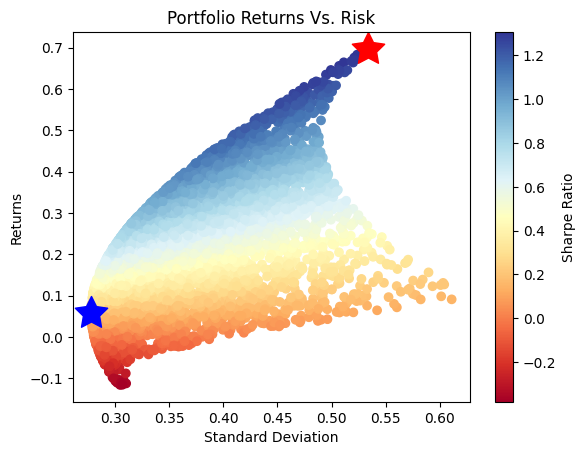

In [9]:
# This is so I can see the plot inside of my Jupyter Notebook.
%matplotlib inline

# Plot the data on a Scatter plot.
plt.scatter(
    y=simulations_df['Returns'],
    x=simulations_df['Volatility'],
    c=simulations_df['Sharpe Ratio'],
    cmap='RdYlBu'
)

# Give the Plot some labels, and titles.
plt.title('Portfolio Returns Vs. Risk')
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Standard Deviation')
plt.ylabel('Returns')

# Plot the Max Sharpe Ratio, using a `Red Star`.
plt.scatter(
    max_sharpe_ratio[1],
    max_sharpe_ratio[0],
    marker=(5, 1, 0),
    color='r',
    s=600
)

# Plot the Min Volatility, using a `Blue Star`.
plt.scatter(
    min_volatility[1],
    min_volatility[0],
    marker=(5, 1, 0),
    color='b',
    s=600
)

# Finally, show the plot.
plt.show()

# Optimization

Alright, now remember that up above I mentioned that we would be exploring multiple ways to optimize our portfolio. The first was using Monte Carlo Simulation that would try thousands of random values and find the best values. The draw back to using the Monte Carlo Simulation is that it's not the most efficent way to find the optimial values. Instead we can use mathematical techniques to easily arrive at the optimial values.

To help run this new optimization method, we will need to define a few more functions that we will use in our method. The first function is the `get_metrics()` function which will return the metrics for a given set of weights provided. In other words, think of it as a "lookup function" where we can return the results of a certain weight. The second function is the `neg_sharpe` function which is used as a minimization function. The minimization function is used to help find the values which results in the lowest sharpe ratio. In Scipy’s optimize function, there’s no `maximize`, so as an objective function you need to pass something that should be minimized.

The third function is `check_sum` function which is used as a constraint. What is will do is make sure that the weights that are passed through meet the constraint that we must have a portfolio allocation equal 100%, not more and not less.

In [10]:
def get_metrics(weights: list) -> np.array:
    """
    ### Overview:
    ----
    With a given set of weights, return the portfolio returns,
    the portfolio volatility, and the portfolio sharpe ratio.

    ### Arguments:
    ----
    weights (list): An array of portfolio weights.

    ### Returns:
    ----
    (np.array): An array containg return value, a volatility value,
        and a sharpe ratio.
    """

    # Convert to a Numpy Array.
    weights = np.array(weights)

    # Calculate the returns, remember to annualize them (252).
    ret = np.sum(log_return.mean() * weights) * 252

    # Calculate the volatility, remember to annualize them (252).
    vol = np.sqrt(
        np.dot(weights.T, np.dot(log_return.cov() * 252, weights))
    )

    # Calculate the Sharpe Ratio.
    sr = ret / vol

    return np.array([ret, vol, sr])

def grab_negative_sharpe(weights: list) -> np.array:
    """The function used to minimize the Sharpe Ratio.

    ### Arguments:
    ----
    weights (list): The weights, we are testing to see
        if it's the minimum.

    ### Returns:
    ----
    (np.array): An numpy array of the portfolio metrics.
    """
    return get_metrics(weights)[2] - 1

def grab_volatility(weights: list) -> np.array:
    """The function used to minimize the Sharpe Ratio.

    ### Arguments:
    ----
    weights (list): The weights, we are testing to see
        if it's the minimum.

    ### Returns:
    ----
    (np.array): An numpy array of the portfolio metrics.
    """
    return get_metrics(weights)[1]

def check_sum(weights: list) -> float:
    """Ensure the allocations of the "weights", sums to 1 (100%)

    ### Arguments:
    ----
    weights (list): The weights we want to check to see
        if they sum to 1.

    ### Returns:
    ----
    float: The different between 1 and the sum of the weights.
    """
    return np.sum(weights) - 1

Okay with our functions now defined, let's run the optimization using the `scipy.optimization` module. This module has a function called `minimize` which we can use to help our optimial values. However, we need to do a few things before we run it. First, we need to define bounds which tells the minimize function that each of our positions can only be between 0% and 100% of the allocation. Second, we need to define the constraint which will be a `fun`(function) that ensures we `equ`(equal) a 100% allocated portfolio. In other words, we use all the "capital" we can. Third, we need to define our initial guess of the weights. The initial guess can be anything but in this case let's make it easy and start with an equally distirbuted portofolio. In this case we have 4 symbols so each symbol will be 25% of the portfolio.

Once we've define this steps we can run the optimization by passing through the arguments defined and defining the `method` as `SLSQP` which is short for `Sequential Least Squares Programming`. Now, the different optimization methods are a whole different topic and is outside the scope of this tutorial. Once we run the `minimize` method we can grab the results.

The first is the results of our minimization operation. Inside the results, you'll see the optimize sharpe ration defined by the `fun` value. We can then take the `optimized_weights` defined by the `optimized_sharpe.x` values, and use them to return the different metrics we have for our portfolio.

In [11]:
# Define the boundaries for each symbol. Remember I can only invest up to 100% of my capital into a single asset.
bounds = tuple((0, 1) for symbol in range(number_of_symbols))

# Define the constraints, here I'm saying that the sum of each weight must not exceed 100%.
constraints = ({'type': 'eq', 'fun': check_sum})

# We need to create an initial guess to start with,
# and usually the best initial guess is just an
# even distribution. In this case 25% for each of the 4 stocks.
init_guess = number_of_symbols * [1 / number_of_symbols]

# Perform the operation to minimize the risk.
optimized_sharpe = sci_opt.minimize(
    grab_negative_sharpe, # minimize this.
    init_guess, # Start with these values.
    method='SLSQP',
    bounds=bounds, # don't exceed these bounds.
    constraints=constraints # make sure you don't exceed the 100% constraint.
)

# Print the results.
print('')
print('='*80)
print('OPTIMIZED SHARPE RATIO:')
print('-'*80)
print(optimized_sharpe)
print('-'*80)


OPTIMIZED SHARPE RATIO:
--------------------------------------------------------------------------------
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -1.4341914504236746
       x: [ 4.534e-12  5.359e-12  1.000e+00]
     nit: 5
     jac: [ 2.190e+00  3.402e-01 -0.000e+00]
    nfev: 20
    njev: 5
--------------------------------------------------------------------------------


In [12]:
# Grab the metrics.
optimized_metrics = get_metrics(weights=optimized_sharpe.x)

# Print the Optimized Weights.
print('')
print('='*80)
print('OPTIMIZED WEIGHTS:')
print('-'*80)
print(optimized_sharpe.x)
print('-'*80)


# Print the Optimized Metrics.
print('')
print('='*80)
print('OPTIMIZED METRICS:')
print('-'*80)
print(optimized_metrics)
print('-'*80)


OPTIMIZED WEIGHTS:
--------------------------------------------------------------------------------
[4.53421033e-12 5.35871347e-12 1.00000000e+00]
--------------------------------------------------------------------------------

OPTIMIZED METRICS:
--------------------------------------------------------------------------------
[-0.14263619  0.32850991 -0.43419145]
--------------------------------------------------------------------------------


In [13]:
# Define the boundaries for each symbol. Remember I can only invest up to 100% of my capital into a single asset.
bounds = tuple((0, 1) for symbol in range(number_of_symbols))

# Define the constraints, here I'm saying that the sum of each weight must not exceed 100%.
constraints = ({'type': 'eq', 'fun': check_sum})

# We need to create an initial guess to start with,
# and usually the best initial guess is just an
# even distribution. In this case 25% for each of the 4 stocks.
init_guess = number_of_symbols * [1 / number_of_symbols]

# Perform the operation to minimize the risk.
optimized_volatility = sci_opt.minimize(
    grab_volatility, # minimize this.
    init_guess, # Start with these values.
    method='SLSQP',
    bounds=bounds, # don't exceed these bounds.
    constraints=constraints # make sure you don't exceed the 100% constraint.
)

# Print the results.
print('')
print('='*80)
print('OPTIMIZED VOLATILITY RATIO:')
print('-'*80)
print(optimized_volatility)
print('-'*80)


OPTIMIZED VOLATILITY RATIO:
--------------------------------------------------------------------------------
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.2775826680366228
       x: [ 2.068e-01  9.574e-02  6.974e-01]
     nit: 5
     jac: [ 2.786e-01  2.770e-01  2.774e-01]
    nfev: 21
    njev: 5
--------------------------------------------------------------------------------


In [14]:
# Grab the metrics.
optimized_metrics = get_metrics(weights=optimized_volatility.x)

# Print the Optimized Weights.
print('')
print('='*80)
print('OPTIMIZED WEIGHTS:')
print('-'*80)
print(optimized_volatility.x)
print('-'*80)


# Print the Optimized Metrics.
print('')
print('='*80)
print('OPTIMIZED METRICS:')
print('-'*80)
print(optimized_metrics)
print('-'*80)


OPTIMIZED WEIGHTS:
--------------------------------------------------------------------------------
[0.2068413  0.09574473 0.69741397]
--------------------------------------------------------------------------------

OPTIMIZED METRICS:
--------------------------------------------------------------------------------
[0.05769622 0.27758267 0.20785239]
--------------------------------------------------------------------------------
